# 資料前處理 澎湖中屯電廠
2017-2020澎湖中屯電廠發電度數與氣候

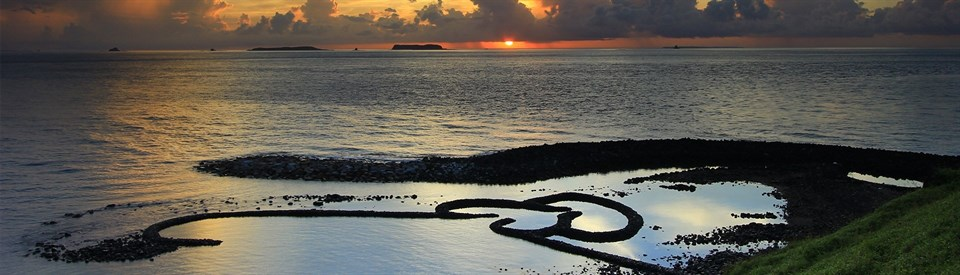

# 氣候特徵

In [ ]:
import pandas as pd
import numpy as np
# 假設有CSV文件包含所有所需數據
data2 = pd.read_csv('/content/活頁簿1.xlsx - 工作表11.csv')
# 查看數據
print(data2.head())


   Year  Month  day 能源別/Type of Energy        發電站名稱/Station Name  \
0  2017      1    1  陸域風力/Onshore Wind  中屯風電/Zhongtun Wind Power   
1  2017      1    2  陸域風力/Onshore Wind  中屯風電/Zhongtun Wind Power   
2  2017      1    3  陸域風力/Onshore Wind  中屯風電/Zhongtun Wind Power   
3  2017      1    4  陸域風力/Onshore Wind  中屯風電/Zhongtun Wind Power   
4  2017      1    5  陸域風力/Onshore Wind  中屯風電/Zhongtun Wind Power   

   發電量(度)/Power Generation(kWh)  測站氣壓(hPa)  海平面氣壓(hPa)  測站最高氣壓(hPa)  \
0                         54144     1019.5      1020.9       1021.5   
1                         17300     1018.5      1019.9       1020.4   
2                         49044     1017.9      1019.2       1019.7   
3                         29332     1016.7      1018.1       1018.8   
4                          5723     1015.3      1016.7       1017.2   

   測站最低氣壓(hPa)  ...  降水時數(hour)  最大十分鐘降水量(mm)  最大六十分鐘降水量(mm)  日照時數(hour)  \
0       1017.5  ...         0.0           0.0            0.0         0.3   
1       1016

In [ ]:
# 假設data已經被讀取
# 將所有 'x' 和 '/' 值替換為 NaN
data2.replace(['X', '/', '--'], np.nan, inplace=True)
columns_to_fill = [col for col in data2.columns if col not in ['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']]

# 選擇數值列進行平均值計算
numeric_data2 = data2[columns_to_fill].apply(pd.to_numeric, errors='coerce')
monthly_avg2 = numeric_data2.groupby(data2['Month']).transform('mean')
# 定義一個函數來填補缺失值
def fill_missing_with_monthly_avg(row, col_name):
    if pd.isnull(row[col_name]):
        return monthly_avg2.loc[row.name, col_name]
    else:
        return row[col_name]

# 對每個需要填補的列應用這個函數
for col in columns_to_fill:
    data2[col] = data2.apply(lambda row: fill_missing_with_monthly_avg(row, col), axis=1)

# 查看填補後的數據
print(data2.head())

   Year  Month  day 能源別/Type of Energy        發電站名稱/Station Name  \
0  2017      1    1  陸域風力/Onshore Wind  中屯風電/Zhongtun Wind Power   
1  2017      1    2  陸域風力/Onshore Wind  中屯風電/Zhongtun Wind Power   
2  2017      1    3  陸域風力/Onshore Wind  中屯風電/Zhongtun Wind Power   
3  2017      1    4  陸域風力/Onshore Wind  中屯風電/Zhongtun Wind Power   
4  2017      1    5  陸域風力/Onshore Wind  中屯風電/Zhongtun Wind Power   

   發電量(度)/Power Generation(kWh)  測站氣壓(hPa)  海平面氣壓(hPa)  測站最高氣壓(hPa)  \
0                         54144     1019.5      1020.9       1021.5   
1                         17300     1018.5      1019.9       1020.4   
2                         49044     1017.9      1019.2       1019.7   
3                         29332     1016.7      1018.1       1018.8   
4                          5723     1015.3      1016.7       1017.2   

   測站最低氣壓(hPa)  ...  降水時數(hour)  最大十分鐘降水量(mm)  最大六十分鐘降水量(mm)  日照時數(hour)  \
0       1017.5  ...         0.0           0.0            0.0         0.3   
1       1016

# 加入風機時數

In [ ]:
import pandas as pd
import numpy as np
# 假設有CSV文件包含所有所需數據
data = pd.read_csv('/content/活頁簿1.xlsx - 工作表8.csv')
# 查看數據
print(data.head())


   Year  Month  day 能源別/Type of Energy        發電站名稱/Station Name  \
0  2017      1    1  陸域風力/Onshore Wind  中屯風電/Zhongtun Wind Power   
1  2017      1    2  陸域風力/Onshore Wind  中屯風電/Zhongtun Wind Power   
2  2017      1    3  陸域風力/Onshore Wind  中屯風電/Zhongtun Wind Power   
3  2017      1    4  陸域風力/Onshore Wind  中屯風電/Zhongtun Wind Power   
4  2017      1    5  陸域風力/Onshore Wind  中屯風電/Zhongtun Wind Power   

   發電量(度)/Power Generation(kWh)  風機1號平均發電時數  風機2號平均發電時數  風機3號平均發電時數  \
0                         54144   21.137097        24.0    19.29086   
1                         17300   21.137097        24.0    19.29086   
2                         49044   21.137097        24.0    19.29086   
3                         29332   21.137097        24.0    19.29086   
4                          5723   21.137097        24.0    19.29086   

   風機4號平均發電時數  ...  降水時數(hour)  最大十分鐘降水量(mm)  最大六十分鐘降水量(mm)  日照時數(hour)  \
0   21.715054  ...         0.0           0.0            0.0         0.3   
1   21.715054 

In [ ]:
# 假設data已經被讀取
# 將所有 'x' 和 '/' 值替換為 NaN
data.replace(['X', '/', '--'], np.nan, inplace=True)
columns_to_fill = [col for col in data.columns if col not in ['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']]

# 選擇數值列進行平均值計算
numeric_data = data[columns_to_fill].apply(pd.to_numeric, errors='coerce')
monthly_avg = numeric_data.groupby(data['Month']).transform('mean')
# 定義一個函數來填補缺失值
def fill_missing_with_monthly_avg(row, col_name):
    if pd.isnull(row[col_name]):
        return monthly_avg.loc[row.name, col_name]
    else:
        return row[col_name]

# 對每個需要填補的列應用這個函數
for col in columns_to_fill:
    data[col] = data.apply(lambda row: fill_missing_with_monthly_avg(row, col), axis=1)

# 查看填補後的數據
print(data.head())

   Year  Month  day 能源別/Type of Energy        發電站名稱/Station Name  \
0  2017      1    1  陸域風力/Onshore Wind  中屯風電/Zhongtun Wind Power   
1  2017      1    2  陸域風力/Onshore Wind  中屯風電/Zhongtun Wind Power   
2  2017      1    3  陸域風力/Onshore Wind  中屯風電/Zhongtun Wind Power   
3  2017      1    4  陸域風力/Onshore Wind  中屯風電/Zhongtun Wind Power   
4  2017      1    5  陸域風力/Onshore Wind  中屯風電/Zhongtun Wind Power   

   發電量(度)/Power Generation(kWh)  風機1號平均發電時數  風機2號平均發電時數  風機3號平均發電時數  \
0                         54144   21.137097        24.0    19.29086   
1                         17300   21.137097        24.0    19.29086   
2                         49044   21.137097        24.0    19.29086   
3                         29332   21.137097        24.0    19.29086   
4                          5723   21.137097        24.0    19.29086   

   風機4號平均發電時數  ...  降水時數(hour)  最大十分鐘降水量(mm)  最大六十分鐘降水量(mm)  日照時數(hour)  \
0   21.715054  ...         0.0           0.0            0.0         0.3   
1   21.715054 

# 氣象特徵

#  LSTM預測每日發電度數

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - loss: 2.4821 - val_loss: 0.9352
Epoch 2/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 1.8371 - val_loss: 0.9327
Epoch 3/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 1.4221 - val_loss: 0.9425
Epoch 4/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 1.4389 - val_loss: 0.9421
Epoch 5/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 1.1636 - val_loss: 0.9407
Epoch 6/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 1.0261 - val_loss: 0.9335
Epoch 7/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.8202 - val_loss: 0.9299
Epoch 8/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.8136 - val_loss: 0.9169
Epoch 9/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.7707 - val_loss: 0.9072
Epoch 10/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.6526 - val_loss: 0.8944
Epoch 11/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.6070 - val_loss: 0.8814
Epoch 12/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step

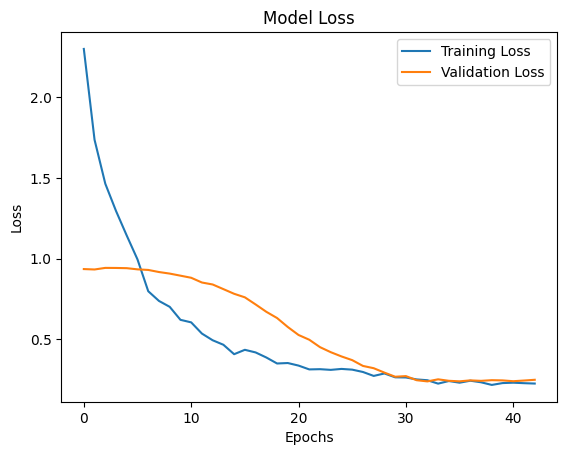

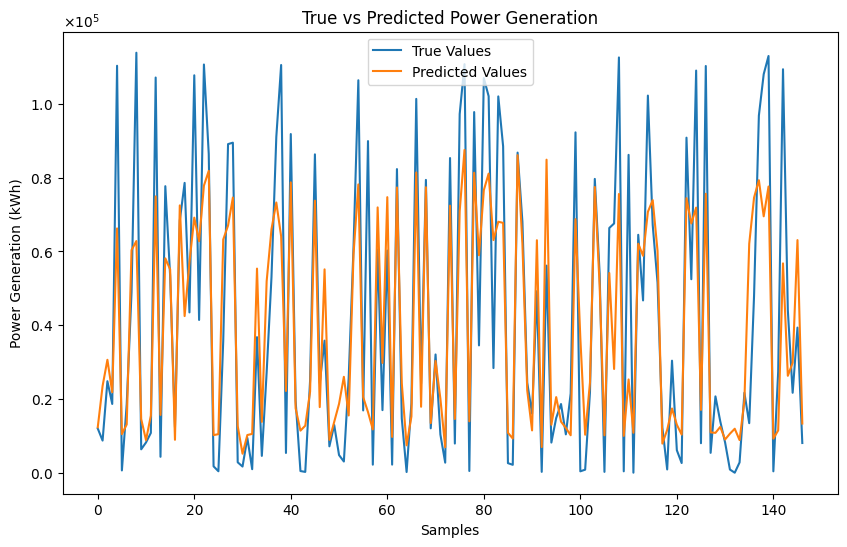

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# 假設 data2 是您的數據集

# 確保所有列都是數值型
for column in data2.columns:
    if column not in ['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']:
        data2[column] = pd.to_numeric(data2[column], errors='coerce')

# 進行 NaN 處理
for column in data2.columns:
    if column not in ['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']:
        monthly_avg = data2.groupby('Month')[column].transform('mean')
        data2[column] = data2[column].fillna(monthly_avg)

# 資料標準化
scaler = StandardScaler()
data2_scaled = scaler.fit_transform(data2.drop(columns=['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']))
mean_scaler = scaler.mean_
scale_scaler = scaler.scale_

# 將標準化資料轉回 DataFrame 以便操作
data2_scaled = pd.DataFrame(data2_scaled, columns=data2.columns.drop(['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']))

# 定義要加大權重的特徵
weighted_features = ['風速(m/s)', '風向(360degree)', '最大瞬間風(m/s)', '最大瞬間風風向(360degree)']
data2_scaled[weighted_features] = data2_scaled[weighted_features] * 2

# 準備訓練和測試資料
X = data2_scaled.drop(columns=['發電量(度)/Power Generation(kWh)'])
y = data2_scaled['發電量(度)/Power Generation(kWh)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
X_train = np.expand_dims(X_train.values, axis=1)
X_test = np.expand_dims(X_test.values, axis=1)

# 建立 LSTM 模型
model = Sequential()
model.add(LSTM(256, activation='relu', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(LSTM(256, activation='relu', return_sequences=True))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(LSTM(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# 訓練模型
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=500, batch_size=64, validation_split=0.1, callbacks=[early_stopping])

# 進行預測
y_pred_scaled = model.predict(X_test)
y_pred_original = y_pred_scaled.flatten() * scale_scaler[0] + mean_scaler[0]
y_test_original = y_test.values * scale_scaler[0] + mean_scaler[0]

# 計算評估指標
mae = mean_absolute_error(y_test_original, y_pred_original)
mse = mean_squared_error(y_test_original, y_pred_original)
rmse = np.sqrt(mse)

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(y_test_original, y_pred_original)

print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'Mean Absolute Percentage Error: {mape}')

# 繪製訓練過程中的損失圖
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 繪製預測結果與真實值的對比圖
plt.figure(figsize=(10, 6))
plt.plot(y_test_original, label='True Values')
plt.plot(y_pred_original, label='Predicted Values')
plt.title('True vs Predicted Power Generation')
plt.xlabel('Samples')
plt.ylabel('Power Generation (kWh)')

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

plt.legend()
plt.show()


# TCN預測每日發電度數

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 1, 25)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ tcn_block_6 (TCNBlock)               │ (None, 1, 128)              │          10,368 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ tcn_block_7 (TCNBlock)               │ (None, 1, 256)              │          99,840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ tcn_block_8 (TCNBlock)               │ (None, 1, 512)              │         396,288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 507,009 (1.93 MB)

 Trainable params: 505,217 (1.93 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 222ms/step - loss: 7.1986 - val_loss: 0.6677
Epoch 2/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 242ms/step - loss: 1.3943 - val_loss: 0.5289
Epoch 3/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 193ms/step - loss: 1.2626 - val_loss: 0.3515
Epoch 4/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - loss: 1.5946 - val_loss: 0.9061
Epoch 5/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 4.2378 - val_loss: 0.8512
Epoch 6/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - loss: 2.0147 - val_loss: 0.7683
Epoch 7/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - loss: 1.7139 - val_loss: 1.1302
Epoch 8/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 1.9746 - val_loss: 0.5915
Epoch 9/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 1.2024 - val_loss: 0.4628
Epoch 10/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 1.0909 - val_loss: 0.3971
Epoch 11/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 0.7756 - val_loss: 0.4080
Epoch 12/10000
19/19 ━━━

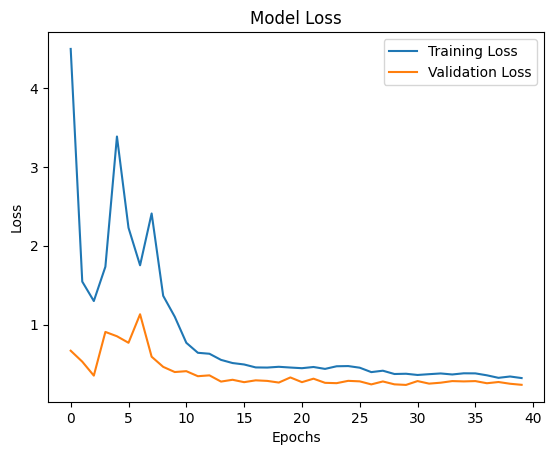

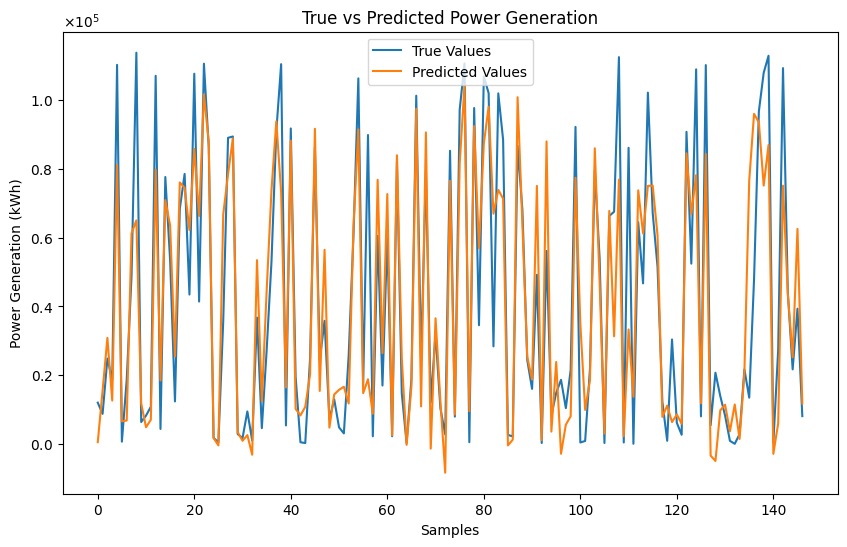

In [ ]:
from keras.layers import Input, Add, Activation
from keras.models import Model

# 定義 TCN 層
class TCNBlock(Layer):
    def __init__(self, filters, kernel_size, dilation_rate):
        super(TCNBlock, self).__init__()
        self.conv = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)
        self.batch_norm = BatchNormalization()
        self.dropout = Dropout(0.3)
        self.activation = Activation('relu')
        self.residual_conv = Conv1D(filters, 1)  # For residual connection

    def call(self, inputs):
        x = self.conv(inputs)
        x = self.batch_norm(x)
        x = self.activation(x)
        x = self.dropout(x)
        residual = self.residual_conv(inputs)
        return Add()([x, residual])

# 建立 TCN 模型
def create_tcn_model(input_shape):
    inputs = Input(shape=input_shape)
    x = TCNBlock(128, kernel_size=2, dilation_rate=1)(inputs)
    x = TCNBlock(256, kernel_size=2, dilation_rate=2)(x)
    x = TCNBlock(512, kernel_size=2, dilation_rate=4)(x)
    x = Flatten()(x)
    x = Dense(1)(x)
    model = Model(inputs, x)
    return model

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, Conv1D, Flatten
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# 假設數據已經被讀取到變量 data2 中

# 確保所有列都是數值型
for column in data2.columns:
    if column not in ['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']:
        data2[column] = pd.to_numeric(data2[column], errors='coerce')

# 進行 NaN 處理
for column in data2.columns:
    if column not in ['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']:
        monthly_avg = data2.groupby('Month')[column].transform('mean')
        data2[column] = data2[column].fillna(monthly_avg)

# 資料標準化
scaler = StandardScaler()
data2_scaled = scaler.fit_transform(data2.drop(columns=['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']))
mean_scaler = scaler.mean_
scale_scaler = scaler.scale_

# 將標準化資料轉回 DataFrame 以便操作
data2_scaled = pd.DataFrame(data2_scaled, columns=data2.columns.drop(['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']))

# 定義要加大權重的特徵
weighted_features = ['風速(m/s)', '風向(360degree)', '最大瞬間風(m/s)', '最大瞬間風風向(360degree)']
data2_scaled[weighted_features] = data2_scaled[weighted_features] * 2

# 準備訓練和測試資料
X = data2_scaled.drop(columns=['發電量(度)/Power Generation(kWh)'])
y = data2_scaled['發電量(度)/Power Generation(kWh)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
X_train = np.expand_dims(X_train.values, axis=1)
X_test = np.expand_dims(X_test.values, axis=1)

# 創建並編譯模型
input_shape = (X_train.shape[1], X_train.shape[2])
model = create_tcn_model(input_shape)
model.compile(optimizer='adam', loss='mse')

# 顯示模型摘要
model.summary()

# 訓練模型
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=10000, batch_size=64, validation_split=0.1, callbacks=[early_stopping])

# 進行預測
y_pred_scaled = model.predict(X_test)
y_pred_original = y_pred_scaled.flatten() * scale_scaler[0] + mean_scaler[0]
y_test_original = y_test.values * scale_scaler[0] + mean_scaler[0]

# 計算評估指標
mae = mean_absolute_error(y_test_original, y_pred_original)
mse = mean_squared_error(y_test_original, y_pred_original)
rmse = np.sqrt(mse)

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(y_test_original, y_pred_original)

print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'Mean Absolute Percentage Error: {mape}')

# 繪製訓練過程中的損失圖
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 繪製預測結果與真實值的對比圖
plt.figure(figsize=(10, 6))
plt.plot(y_test_original, label='True Values')
plt.plot(y_pred_original, label='Predicted Values')
plt.title('True vs Predicted Power Generation')
plt.xlabel('Samples')
plt.ylabel('Power Generation (kWh)')

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

plt.legend()
plt.show()


# 氣象特徵＋風機時數

# LSTM預測每日發電度數


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 158ms/step - loss: 2.9254 - val_loss: 0.9307
Epoch 2/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 1.8541 - val_loss: 0.9265
Epoch 3/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 1.5672 - val_loss: 0.9233
Epoch 4/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 1.3919 - val_loss: 0.9198
Epoch 5/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 1.1020 - val_loss: 0.9154
Epoch 6/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.9215 - val_loss: 0.9064
Epoch 7/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.8564 - val_loss: 0.9008
Epoch 8/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.7441 - val_loss: 0.8930
Epoch 9/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.7863 - val_loss: 0.8805
Epoch 10/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.6549 - val_loss: 0.8547
Epoch 11/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.5873 - val_loss: 0.8452
Epoch 12/500
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/st

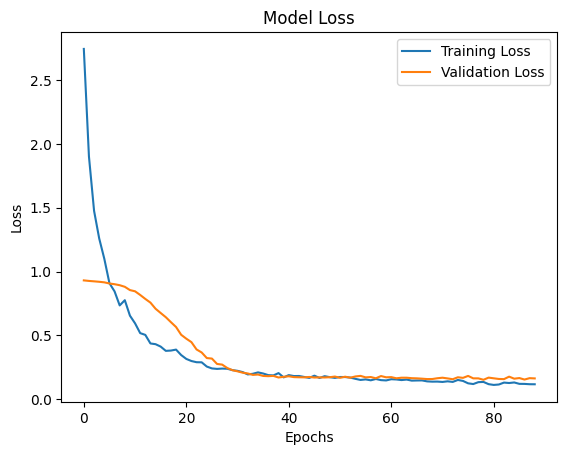

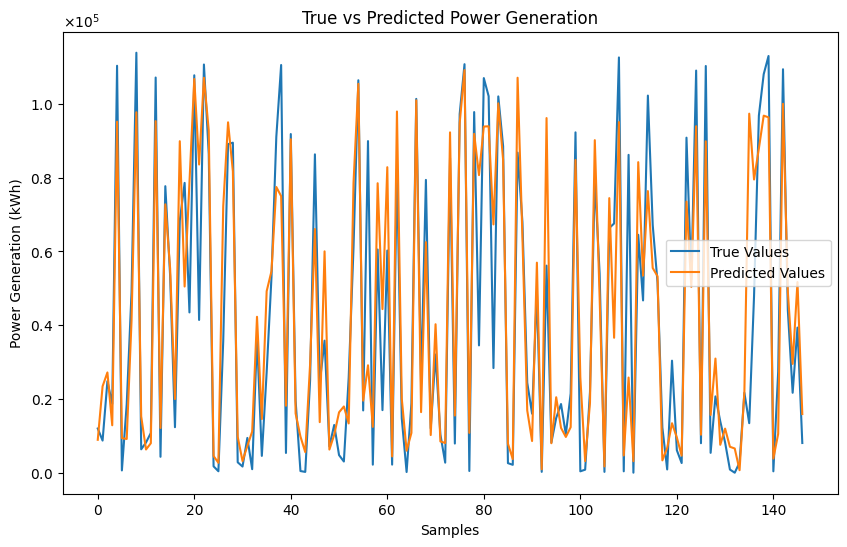

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter


# 確保所有列都是數值型
for column in data.columns:
    if column not in ['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']:
        data[column] = pd.to_numeric(data[column], errors='coerce')

# 進行 NaN 處理
for column in data.columns:
    if column not in ['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']:
        monthly_avg = data.groupby('Month')[column].transform('mean')
        data[column] = data[column].fillna(monthly_avg)

# 資料標準化
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.drop(columns=['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']))
mean_scaler = scaler.mean_
scale_scaler = scaler.scale_

# 將標準化資料轉回 DataFrame 以便操作
data_scaled = pd.DataFrame(data_scaled, columns=data.columns.drop(['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']))

# 定義要加大權重的特徵
weighted_features = ['風速(m/s)', '風向(360degree)', '最大瞬間風(m/s)', '最大瞬間風風向(360degree)']
data_scaled[weighted_features] = data_scaled[weighted_features] * 2

# 準備訓練和測試資料
X = data_scaled.drop(columns=['發電量(度)/Power Generation(kWh)'])
y = data_scaled['發電量(度)/Power Generation(kWh)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
X_train = np.expand_dims(X_train.values, axis=1)
X_test = np.expand_dims(X_test.values, axis=1)

# 建立 LSTM 模型
model = Sequential()
model.add(LSTM(256, activation='relu', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(LSTM(256, activation='relu', return_sequences=True))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(LSTM(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# 訓練模型
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=500, batch_size=64, validation_split=0.1, callbacks=[early_stopping])

# 進行預測
y_pred_scaled = model.predict(X_test)
y_pred_original = y_pred_scaled.flatten() * scale_scaler[0] + mean_scaler[0]
y_test_original = y_test.values * scale_scaler[0] + mean_scaler[0]

# 計算評估指標
mae = mean_absolute_error(y_test_original, y_pred_original)
mse = mean_squared_error(y_test_original, y_pred_original)
rmse = np.sqrt(mse)

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(y_test_original, y_pred_original)

print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'Mean Absolute Percentage Error: {mape}')

# 繪製訓練過程中的損失圖
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 繪製預測結果與真實值的對比圖
plt.figure(figsize=(10, 6))
plt.plot(y_test_original, label='True Values')
plt.plot(y_pred_original, label='Predicted Values')
plt.title('True vs Predicted Power Generation')
plt.xlabel('Samples')
plt.ylabel('Power Generation (kWh)')

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

plt.legend()
plt.show()


#TCN預測每日發電度數

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)           │ (None, 1, 33)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ tcn_block_24 (TCNBlock)              │ (None, 1, 128)              │          13,440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ tcn_block_25 (TCNBlock)              │ (None, 1, 256)              │          99,840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ tcn_block_26 (TCNBlock)              │ (None, 1, 512)              │         396,288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_8 (Flatten)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 510,081 (1.95 MB)

 Trainable params: 508,289 (1.94 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - loss: 5.0756 - val_loss: 1.0387
Epoch 2/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - loss: 1.6228 - val_loss: 0.5313
Epoch 3/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step - loss: 2.1108 - val_loss: 1.0263
Epoch 4/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 2.8825 - val_loss: 0.6288
Epoch 5/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 2.1873 - val_loss: 0.4688
Epoch 6/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 1.6539 - val_loss: 0.4631
Epoch 7/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.9523 - val_loss: 0.4483
Epoch 8/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 0.7959 - val_loss: 0.3651
Epoch 9/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 142ms/step - loss: 0.6713 - val_loss: 0.3451
Epoch 10/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - loss: 0.5656 - val_loss: 0.3659
Epoch 11/10000
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.5238 - val_loss: 0.2658
Epoch 12/10000
19/19 ━

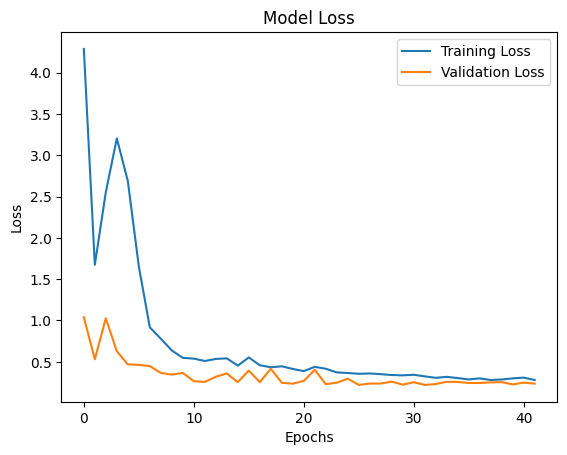

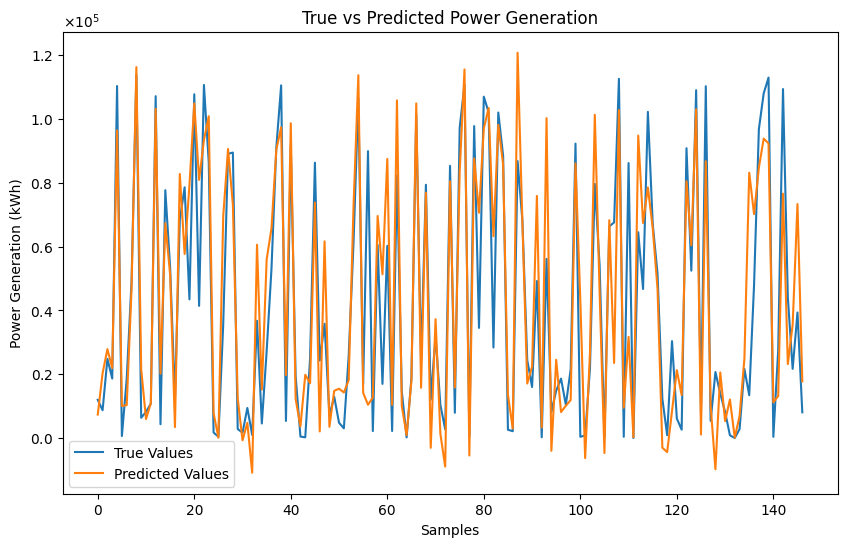

In [ ]:
from keras.layers import Input, Add, Activation
from keras.models import Model

# 定義 TCN 層
class TCNBlock(Layer):
    def __init__(self, filters, kernel_size, dilation_rate):
        super(TCNBlock, self).__init__()
        self.conv = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)
        self.batch_norm = BatchNormalization()
        self.dropout = Dropout(0.3)
        self.activation = Activation('relu')
        self.residual_conv = Conv1D(filters, 1)  # For residual connection

    def call(self, inputs):
        x = self.conv(inputs)
        x = self.batch_norm(x)
        x = self.activation(x)
        x = self.dropout(x)
        residual = self.residual_conv(inputs)
        return Add()([x, residual])

# 建立 TCN 模型
def create_tcn_model(input_shape):
    inputs = Input(shape=input_shape)
    x = TCNBlock(128, kernel_size=2, dilation_rate=1)(inputs)
    x = TCNBlock(256, kernel_size=2, dilation_rate=2)(x)
    x = TCNBlock(512, kernel_size=2, dilation_rate=4)(x)
    x = Flatten()(x)
    x = Dense(1)(x)
    model = Model(inputs, x)
    return model

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, Conv1D, Flatten
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# 假設數據已經被讀取到變量 data2 中

# 確保所有列都是數值型
for column in data.columns:
    if column not in ['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']:
        data[column] = pd.to_numeric(data[column], errors='coerce')

# 進行 NaN 處理
for column in data.columns:
    if column not in ['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']:
        monthly_avg = data.groupby('Month')[column].transform('mean')
        data[column] = data[column].fillna(monthly_avg)

# 資料標準化
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.drop(columns=['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']))
mean_scaler = scaler.mean_
scale_scaler = scaler.scale_

# 將標準化資料轉回 DataFrame 以便操作
data_scaled = pd.DataFrame(data_scaled, columns=data.columns.drop(['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']))

# 定義要加大權重的特徵
weighted_features = ['風速(m/s)', '風向(360degree)', '最大瞬間風(m/s)', '最大瞬間風風向(360degree)']
data_scaled[weighted_features] = data_scaled[weighted_features] * 2

# 準備訓練和測試資料
X = data_scaled.drop(columns=['發電量(度)/Power Generation(kWh)'])
y = data_scaled['發電量(度)/Power Generation(kWh)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
X_train = np.expand_dims(X_train.values, axis=1)
X_test = np.expand_dims(X_test.values, axis=1)

# 創建並編譯模型
input_shape = (X_train.shape[1], X_train.shape[2])
model = create_tcn_model(input_shape)
model.compile(optimizer='adam', loss='mse')

# 顯示模型摘要
model.summary()

# 訓練模型
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=10000, batch_size=64, validation_split=0.1, callbacks=[early_stopping])

# 進行預測
y_pred_scaled = model.predict(X_test)
y_pred_original = y_pred_scaled.flatten() * scale_scaler[0] + mean_scaler[0]
y_test_original = y_test.values * scale_scaler[0] + mean_scaler[0]

# 計算評估指標
mae = mean_absolute_error(y_test_original, y_pred_original)
mse = mean_squared_error(y_test_original, y_pred_original)
rmse = np.sqrt(mse)

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(y_test_original, y_pred_original)


print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'Mean Absolute Percentage Error: {mape}')

# 繪製訓練過程中的損失圖
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 繪製預測結果與真實值的對比圖
plt.figure(figsize=(10, 6))
plt.plot(y_test_original, label='True Values')
plt.plot(y_pred_original, label='Predicted Values')
plt.title('True vs Predicted Power Generation')
plt.xlabel('Samples')
plt.ylabel('Power Generation (kWh)')

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

plt.legend()
plt.show()


# 氣象特徵＋風機時數＋損耗率

# LSTM預測每日發電度數

Columns after NaN processing: Index(['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name',
       '發電量(度)/Power Generation(kWh)', '風機1號平均發電時數', '風機2號平均發電時數',
       '風機3號平均發電時數', '風機4號平均發電時數', '風機5號平均發電時數', '風機6號平均發電時數', '風機7號平均發電時數',
       '風機8號平均發電時數', '測站氣壓(hPa)', '海平面氣壓(hPa)', '測站最高氣壓(hPa)', '測站最低氣壓(hPa)',
       '氣溫(℃)', '最高氣溫(℃)', '最低氣溫(℃)', '露點溫度(℃)', '相對溼度(%)', '最小相對溼度(%)',
       '風速(m/s)', '風向(360degree)', '最大瞬間風(m/s)', '最大瞬間風風向(360degree)',
       '降水量(mm)', '降水時數(hour)', '最大十分鐘降水量(mm)', '最大六十分鐘降水量(mm)', '日照時數(hour)',
       '日照率(%)', '全天空日射量(MJ/㎡)', '能見度(km)', 'A型蒸發量(mm)', '日最高紫外線指數',
       '總雲量(0~10)'],
      dtype='object')
Columns after scaling: Index(['發電量(度)/Power Generation(kWh)', '風機1號平均發電時數', '風機2號平均發電時數',
       '風機3號平均發電時數', '風機4號平均發電時數', '風機5號平均發電時數', '風機6號平均發電時數', '風機7號平均發電時數',
       '風機8號平均發電時數', '測站氣壓(hPa)', '海平面氣壓(hPa)', '測站最高氣壓(hPa)', '測站最低氣壓(hPa)',
       '氣溫(℃)', '最高氣溫(℃)', '最低氣溫(℃)', '露點溫度(℃)', '相對溼度(%)', '最小相對溼度(%)',
       '風速(m/s)', '風

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


串流輸出內容已截斷至最後 5000 行。
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 18.4311 - val_loss: 17.7552 - learning_rate: 1.0000e-05
Epoch 371/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 18.5125 - val_loss: 17.7435 - learning_rate: 1.0000e-05
Epoch 372/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 18.4573 - val_loss: 17.7336 - learning_rate: 1.0000e-05
Epoch 373/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 18.4744 - val_loss: 17.7160 - learning_rate: 1.0000e-05
Epoch 374/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 18.4234 - val_loss: 17.7046 - learning_rate: 1.0000e-05
Epoch 375/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step - loss: 18.4485 - val_loss: 17.6959 - learning_rate: 1.0000e-05
Epoch 376/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 18.5167 - val_loss: 17.6808 - learning_rate: 1.0000e-05
Epoch 377/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 18.4523 - val_loss: 17.6712 - learning_rate: 1.0000e-05
Epoch 378/100000
19/19 ━━

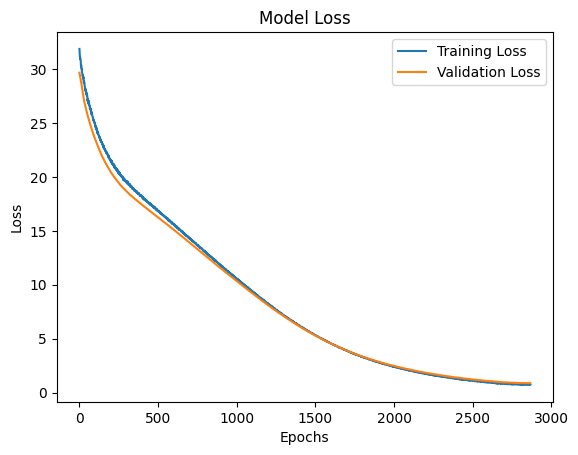

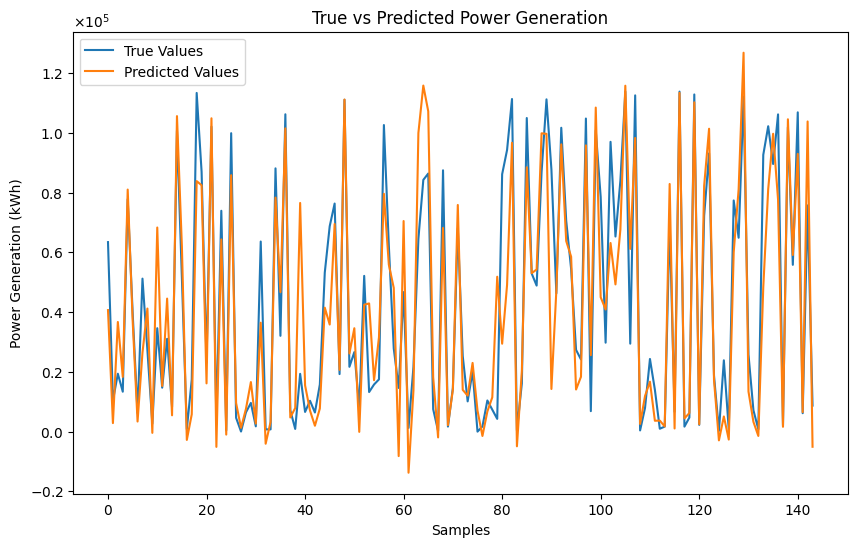

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.feature_selection import SelectKBest, f_regression
from keras.models import Sequential
from keras.layers import LSTM, GRU, Dense, Dropout, BatchNormalization, Bidirectional
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# 假設data已經被讀取
# 將所有 'x' 和 '/' 值替換為 NaN
data.replace(['x', '/', '--'], np.nan, inplace=True)

# 確保所有列都是數值型
for column in data.columns:
    if column not in ['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']:
        data[column] = pd.to_numeric(data[column], errors='coerce')

# 進行 NaN 處理
for column in data.columns:
    if column not in ['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']:
        monthly_avg = data.groupby('Month')[column].transform('mean')
        data[column] = data[column].fillna(monthly_avg)

# 打印檢查列名
print("Columns after NaN processing:", data.columns)

# 創建滯後特徵
lag_features = [
    '風速(m/s)', '風向(360degree)', '最大瞬間風(m/s)', '最大瞬間風風向(360degree)',
    '風機1號平均發電時數', '風機2號平均發電時數', '風機3號平均發電時數', '風機4號平均發電時數',
    '風機5號平均發電時數', '風機6號平均發電時數', '風機7號平均發電時數', '風機8號平均發電時數'
]

# 模擬風機損耗率
initial_decay_rate = 0.00001
monthly_increase_factor = 1.2
yearly_increase_factor = 1.5

# 計算損耗率
decay_rate_list = []
current_decay_rate = initial_decay_rate
for idx, row in data.iterrows():
    if idx > 0:
        if data.loc[idx, 'Year'] != data.loc[idx - 1, 'Year']:
            current_decay_rate *= yearly_increase_factor
        elif data.loc[idx, 'Month'] != data.loc[idx - 1, 'Month']:
            current_decay_rate *= monthly_increase_factor
    decay_rate_list.append(current_decay_rate)

data['損耗率'] = decay_rate_list

# 將損耗率加入滯後特徵
lag_features.append('損耗率')

# 創建更多滯後特徵
for feature in lag_features:
    for lag in range(10, 12):  # 增加滯後特徵的範圍
        data[f'{feature}_lag{lag}'] = data[feature].shift(lag)

# 添加更多移動平均特徵
window_sizes = [21, 30]  # 增加不同窗口大小
for feature in lag_features:
    for window in window_sizes:
        data[f'{feature}_ma{window}'] = data[feature].rolling(window=window).mean()


# 去除包含 NaN 的行（由於滯後特徵的生成）
data.dropna(inplace=True)

# 資料標準化
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.drop(columns=['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']))
mean_scaler = scaler.mean_
scale_scaler = scaler.scale_

# 將標準化資料轉回 DataFrame 以便操作
data_scaled = pd.DataFrame(data_scaled, columns=data.columns.drop(['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']))

# 打印檢查列名
print("Columns after scaling:", data_scaled.columns)

# 定義要加大權重的特徵
weighted_features = [
    '風速(m/s)', '風向(360degree)', '最大瞬間風(m/s)', '最大瞬間風風向(360degree)',
    '風機1號平均發電時數', '風機2號平均發電時數', '風機3號平均發電時數', '風機4號平均發電時數',
    '風機5號平均發電時數', '風機6號平均發電時數', '風機7號平均發電時數', '風機8號平均發電時數', '損耗率'
]
data_scaled[weighted_features] = data_scaled[weighted_features] * 2

# 特徵選擇
X = data_scaled.drop(columns=['發電量(度)/Power Generation(kWh)'])
y = data_scaled['發電量(度)/Power Generation(kWh)']

selector = SelectKBest(score_func=f_regression, k=30)
X_selected = selector.fit_transform(X, y)

# 取得已選特徵的列名
selected_feature_names = X.columns[selector.get_support()]

# 打印選擇的特徵
print("Selected features before adding 強制特徵:", selected_feature_names)

# 定義強制加入的特徵
mandatory_features = [
    '損耗率', '風機1號平均發電時數', '風機2號平均發電時數', '風機3號平均發電時數',
    '風機4號平均發電時數', '風機5號平均發電時數', '風機6號平均發電時數',
    '風機7號平均發電時數', '風機8號平均發電時數'
]

# 如果強制特徵不在已選特徵中，則將其加入
for feature in mandatory_features:
    if feature not in selected_feature_names:
        X_selected = np.concatenate([X_selected, X[[feature]]], axis=1)
        selected_feature_names = np.append(selected_feature_names, feature)

# 打印最終選擇的特徵
print("Selected features after adding 強制特徵:", selected_feature_names)

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.1, random_state=42)
X_train = np.expand_dims(X_train, axis=1)
X_test = np.expand_dims(X_test, axis=1)

# 建立 LSTM 模型
model = Sequential()
model.add(Bidirectional(LSTM(256, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2]), kernel_regularizer='l2')))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(256, activation='relu', return_sequences=True, kernel_regularizer='l2')))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(256, activation='relu', kernel_regularizer='l2')))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(1))

# 使用指定學習率的 Adam 優化器
optimizer = Adam(learning_rate=0.00001)  # 調整學習率
model.compile(optimizer=optimizer, loss='mse')

# 訓練模型
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)
history = model.fit(X_train, y_train, epochs=100000, batch_size=64, validation_split=0.1, callbacks=[early_stopping, reduce_lr])  # 調整batch_size和epochs

# 進行預測
y_pred_scaled = model.predict(X_test)
y_pred_original = y_pred_scaled.flatten() * scale_scaler[0] + mean_scaler[0]
y_test_original = y_test.values * scale_scaler[0] + mean_scaler[0]

# 計算評估指標
mae = mean_absolute_error(y_test_original, y_pred_original)
mse = mean_squared_error(y_test_original, y_pred_original)
rmse = np.sqrt(mse)

def mean_absolute_percentage_error(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mape = mean_absolute_percentage_error(y_test_original, y_pred_original)

print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'Mean Absolute Percentage Error: {mape}')

# 繪製訓練過程中的損失圖
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 繪製預測結果與真實值的對比圖
plt.figure(figsize=(10, 6))
plt.plot(y_test_original, label='True Values')
plt.plot(y_pred_original, label='Predicted Values')
plt.title('True vs Predicted Power Generation')
plt.xlabel('Samples')
plt.ylabel('Power Generation (kWh)')

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

plt.legend()
plt.show()


Columns after NaN processing: Index(['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name',
       '發電量(度)/Power Generation(kWh)', '風機1號平均發電時數', '風機2號平均發電時數',
       '風機3號平均發電時數', '風機4號平均發電時數', '風機5號平均發電時數', '風機6號平均發電時數', '風機7號平均發電時數',
       '風機8號平均發電時數', '測站氣壓(hPa)', '海平面氣壓(hPa)', '測站最高氣壓(hPa)', '測站最低氣壓(hPa)',
       '氣溫(℃)', '最高氣溫(℃)', '最低氣溫(℃)', '露點溫度(℃)', '相對溼度(%)', '最小相對溼度(%)',
       '風速(m/s)', '風向(360degree)', '最大瞬間風(m/s)', '最大瞬間風風向(360degree)',
       '降水量(mm)', '降水時數(hour)', '最大十分鐘降水量(mm)', '最大六十分鐘降水量(mm)', '日照時數(hour)',
       '日照率(%)', '全天空日射量(MJ/㎡)', '能見度(km)', 'A型蒸發量(mm)', '日最高紫外線指數',
       '總雲量(0~10)'],
      dtype='object')
Columns after scaling: Index(['發電量(度)/Power Generation(kWh)', '風機1號平均發電時數', '風機2號平均發電時數',
       '風機3號平均發電時數', '風機4號平均發電時數', '風機5號平均發電時數', '風機6號平均發電時數', '風機7號平均發電時數',
       '風機8號平均發電時數', '測站氣壓(hPa)', '海平面氣壓(hPa)', '測站最高氣壓(hPa)', '測站最低氣壓(hPa)',
       '氣溫(℃)', '最高氣溫(℃)', '最低氣溫(℃)', '露點溫度(℃)', '相對溼度(%)', '最小相對溼度(%)',
       '風速(m/s)', '風

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


串流輸出內容已截斷至最後 5000 行。
Epoch 187/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - loss: 21.6795 - val_loss: 20.8296 - learning_rate: 1.0000e-05
Epoch 188/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 21.6764 - val_loss: 20.8104 - learning_rate: 1.0000e-05
Epoch 189/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 21.6279 - val_loss: 20.7837 - learning_rate: 1.0000e-05
Epoch 190/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 21.8605 - val_loss: 20.7555 - learning_rate: 1.0000e-05
Epoch 191/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 21.7407 - val_loss: 20.7326 - learning_rate: 1.0000e-05
Epoch 192/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 21.7288 - val_loss: 20.7117 - learning_rate: 1.0000e-05
Epoch 193/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - loss: 21.6318 - val_loss: 20.6916 - learning_rate: 1.0000e-05
Epoch 194/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 21.6789 - val_loss: 20.6698 - learning_rate: 1.0000e-05
Epoch 19

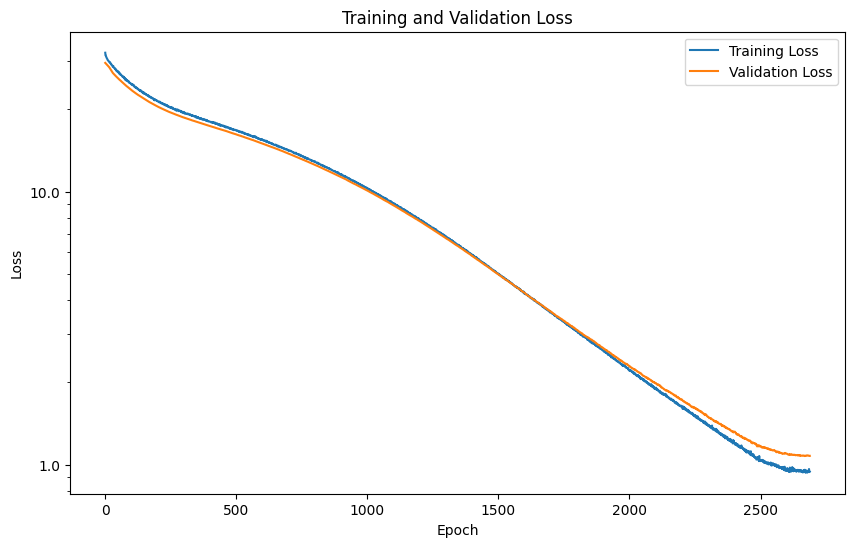

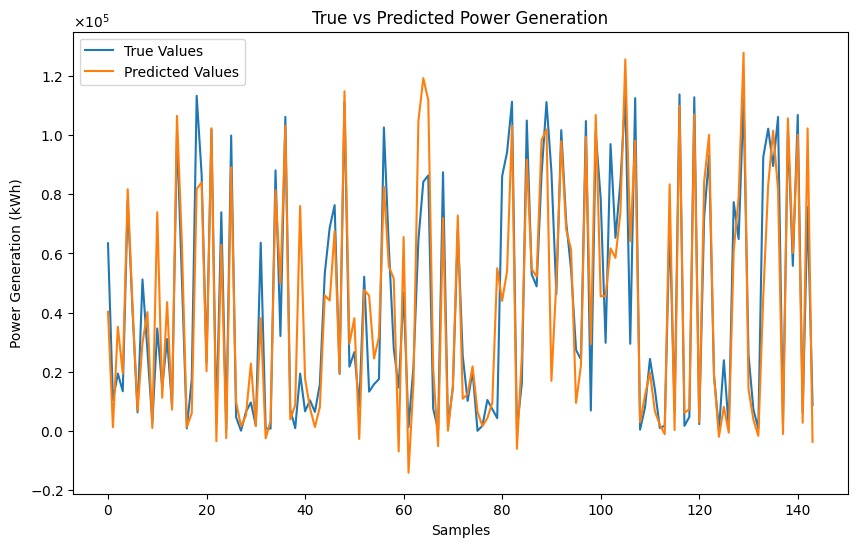

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.feature_selection import SelectKBest, f_regression
from keras.models import Sequential
from keras.layers import LSTM, GRU, Dense, Dropout, BatchNormalization, Bidirectional
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# 假設data已經被讀取
# 將所有 'x' 和 '/' 值替換為 NaN
data.replace(['X', '/'], np.nan, inplace=True)

# 將所有 'X' 和 '/' 值替換為該列的均值
columns_to_fill = [col for col in data.columns if col not in ['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']]
for col in columns_to_fill:
    data[col] = pd.to_numeric(data[col], errors='coerce')  # 轉換為數值型，非數值型轉換為 NaN
    data[col].fillna(data[col].mean(), inplace=True)  # 填補 NaN 值為均值

# 確保所有列都是數值型
for column in data.columns:
    if column not in ['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']:
        data[column] = pd.to_numeric(data[column], errors='coerce')

# 進行 NaN 處理
for column in data.columns:
    if column not in ['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']:
        monthly_avg = data.groupby('Month')[column].transform('mean')
        data[column] = data[column].fillna(monthly_avg)

# 打印檢查列名
print("Columns after NaN processing:", data.columns)

# 創建滯後特徵
lag_features = [
    '風速(m/s)', '風向(360degree)', '最大瞬間風(m/s)', '最大瞬間風風向(360degree)',
    '風機1號平均發電時數', '風機2號平均發電時數', '風機3號平均發電時數', '風機4號平均發電時數',
    '風機5號平均發電時數', '風機6號平均發電時數', '風機7號平均發電時數', '風機8號平均發電時數'
]

# 模擬風機損耗率
initial_decay_rate = 0.00001
monthly_increase_factor = 1.2
yearly_increase_factor = 1.5

# 計算損耗率
decay_rate_list = []
current_decay_rate = initial_decay_rate
for idx, row in data.iterrows():
    if idx > 0:
        if data.loc[idx, 'Year'] != data.loc[idx - 1, 'Year']:
            current_decay_rate *= yearly_increase_factor
        elif data.loc[idx, 'Month'] != data.loc[idx - 1, 'Month']:
            current_decay_rate *= monthly_increase_factor
    decay_rate_list.append(current_decay_rate)

data['損耗率'] = decay_rate_list

# 將損耗率加入滯後特徵
lag_features.append('損耗率')

# 創建更多滯後特徵
for feature in lag_features:
    for lag in range(10, 12):  # 增加滯後特徵的範圍
        data[f'{feature}_lag{lag}'] = data[feature].shift(lag)

# 添加更多移動平均特徵
window_sizes = [21, 30]  # 增加不同窗口大小
for feature in lag_features:
    for window in window_sizes:
        data[f'{feature}_ma{window}'] = data[feature].rolling(window=window).mean()

# 去除包含 NaN 的行（由於滯後特徵的生成）
data.dropna(inplace=True)

# 資料標準化
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.drop(columns=['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']))
mean_scaler = scaler.mean_
scale_scaler = scaler.scale_

# 將標準化資料轉回 DataFrame 以便操作
data_scaled = pd.DataFrame(data_scaled, columns=data.columns.drop(['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']))

# 打印檢查列名
print("Columns after scaling:", data_scaled.columns)

# 定義要加大權重的特徵
weighted_features = [
    '風速(m/s)', '風向(360degree)', '最大瞬間風(m/s)', '最大瞬間風風向(360degree)',
    '風機1號平均發電時數', '風機2號平均發電時數', '風機3號平均發電時數', '風機4號平均發電時數',
    '風機5號平均發電時數', '風機6號平均發電時數', '風機7號平均發電時數', '風機8號平均發電時數', '損耗率'
]
data_scaled[weighted_features] = data_scaled[weighted_features] * 2

# 特徵選擇
X = data_scaled.drop(columns=['發電量(度)/Power Generation(kWh)'])
y = data_scaled['發電量(度)/Power Generation(kWh)']

selector = SelectKBest(score_func=f_regression, k=30)
X_selected = selector.fit_transform(X, y)

# 取得已選特徵的列名
selected_feature_names = X.columns[selector.get_support()]

# 打印選擇的特徵
print("Selected features before adding 強制特徵:", selected_feature_names)

# 定義強制加入的特徵
mandatory_features = [
    '損耗率', '風機1號平均發電時數', '風機2號平均發電時數', '風機3號平均發電時數',
    '風機4號平均發電時數', '風機5號平均發電時數', '風機6號平均發電時數',
    '風機7號平均發電時數', '風機8號平均發電時數'
]

# 如果強制特徵不在已選特徵中，則將其加入
for feature in mandatory_features:
    if feature not in selected_feature_names:
        X_selected = np.concatenate([X_selected, X[[feature]]], axis=1)
        selected_feature_names = np.append(selected_feature_names, feature)

# 打印最終選擇的特徵
print("Selected features after adding 強制特徵:", selected_feature_names)

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.1, random_state=42)
X_train = np.expand_dims(X_train, axis=1)
X_test = np.expand_dims(X_test, axis=1)

# 建立 LSTM 模型
model = Sequential()
model.add(Bidirectional(LSTM(256, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2]), kernel_regularizer='l2')))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(256, activation='relu', return_sequences=True, kernel_regularizer='l2')))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(256, activation='relu', kernel_regularizer='l2')))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(1))

# 使用指定學習率的 Adam 優化器
optimizer = Adam(learning_rate=0.00001)  # 調整學習率
model.compile(optimizer=optimizer, loss='mse')

# 訓練模型
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)
history = model.fit(X_train, y_train, epochs=100000, batch_size=64, validation_split=0.1, callbacks=[early_stopping, reduce_lr])  # 調整batch_size和epochs

# 進行預測
y_pred_scaled = model.predict(X_test)
y_pred_original = y_pred_scaled.flatten() * scale_scaler[0] + mean_scaler[0]
y_test_original = y_test.values * scale_scaler[0] + mean_scaler[0]

# 計算評估指標
mae = mean_absolute_error(y_test_original, y_pred_original)
mse = mean_squared_error(y_test_original, y_pred_original)
rmse = np.sqrt(mse)

def mean_absolute_percentage_error(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mape = mean_absolute_percentage_error(y_test_original, y_pred_original)

print(f'MAE: {mae}')
print(f'RMSE: {rmse}')
print(f'MAPE: {mape}')

# 繪製訓練過程中的損失值變化
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.yscale('log')
plt.gca().yaxis.set_major_formatter(ScalarFormatter())
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# 繪製預測結果與真實值的對比圖
plt.figure(figsize=(10, 6))
plt.plot(y_test_original, label='True Values')
plt.plot(y_pred_original, label='Predicted Values')
plt.title('True vs Predicted Power Generation')
plt.xlabel('Samples')
plt.ylabel('Power Generation (kWh)')

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

plt.legend()
plt.show()

# TCN預測每日發電度數

Columns after scaling: Index(['發電量(度)/Power Generation(kWh)', '風機1號平均發電時數', '風機2號平均發電時數',
       '風機3號平均發電時數', '風機4號平均發電時數', '風機5號平均發電時數', '風機6號平均發電時數', '風機7號平均發電時數',
       '風機8號平均發電時數', '測站氣壓(hPa)', '海平面氣壓(hPa)', '測站最高氣壓(hPa)', '測站最低氣壓(hPa)',
       '氣溫(℃)', '最高氣溫(℃)', '最低氣溫(℃)', '露點溫度(℃)', '相對溼度(%)', '最小相對溼度(%)',
       '風速(m/s)', '風向(360degree)', '最大瞬間風(m/s)', '最大瞬間風風向(360degree)',
       '降水量(mm)', '降水時數(hour)', '最大十分鐘降水量(mm)', '最大六十分鐘降水量(mm)', '日照時數(hour)',
       '日照率(%)', '全天空日射量(MJ/㎡)', '能見度(km)', 'A型蒸發量(mm)', '日最高紫外線指數',
       '總雲量(0~10)', '損耗率', '風速(m/s)_lag10', '風速(m/s)_lag11',
       '風向(360degree)_lag10', '風向(360degree)_lag11', '最大瞬間風(m/s)_lag10',
       '最大瞬間風(m/s)_lag11', '最大瞬間風風向(360degree)_lag10',
       '最大瞬間風風向(360degree)_lag11', '風機1號平均發電時數_lag10', '風機1號平均發電時數_lag11',
       '風機2號平均發電時數_lag10', '風機2號平均發電時數_lag11', '風機3號平均發電時數_lag10',
       '風機3號平均發電時數_lag11', '風機4號平均發電時數_lag10', '風機4號平均發電時數_lag11',
       '風機5號平均發電時數_lag10', '風機5號平均發電時數_lag11', '風機6號平均發電時數_lag10'

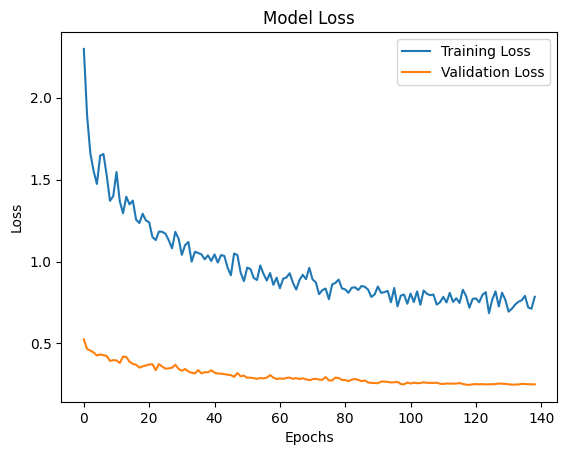

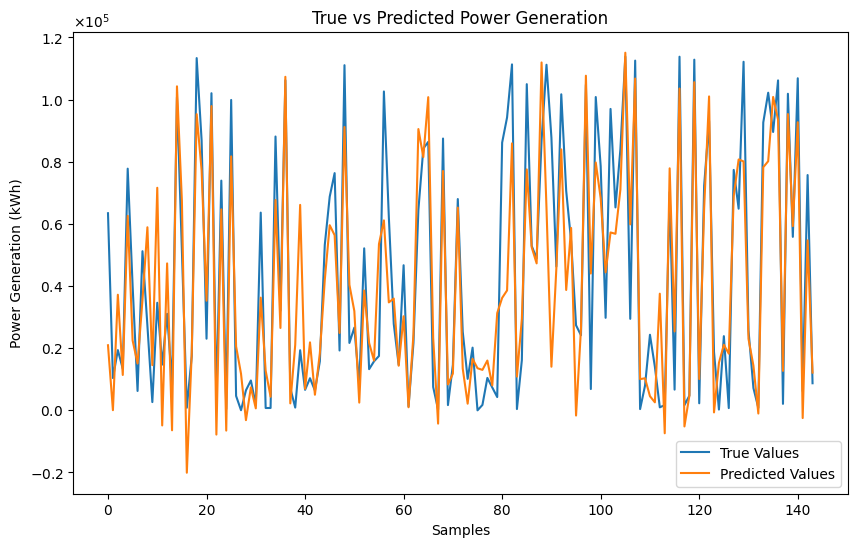

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from keras.models import Model
from keras.layers import Input, Dense, Dropout, BatchNormalization, Conv1D, Flatten, Add, Activation, Layer
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from tensorflow.keras.optimizers import Adam

# 假設data已經被讀取
# 將所有 'x' 和 '/' 值替換為 NaN
data.replace(['X', '/', '--'], np.nan, inplace=True)

# 確保所有列都是數值型
for column in data.columns:
    if column not in ['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']:
        data[column] = pd.to_numeric(data[column], errors='coerce')

# 進行 NaN 處理
for column in data.columns:
    if column not in ['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']:
        monthly_avg = data.groupby('Month')[column].transform('mean')
        data[column] = data[column].fillna(monthly_avg)

# 創建滯後特徵
lag_features = [
    '風速(m/s)', '風向(360degree)', '最大瞬間風(m/s)', '最大瞬間風風向(360degree)',
    '風機1號平均發電時數', '風機2號平均發電時數', '風機3號平均發電時數', '風機4號平均發電時數',
    '風機5號平均發電時數', '風機6號平均發電時數', '風機7號平均發電時數', '風機8號平均發電時數'
]

# 模擬風機損耗率
initial_decay_rate = 0.00001
monthly_increase_factor = 1.2
yearly_increase_factor = 1.5

# 計算損耗率
decay_rate_list = []
current_decay_rate = initial_decay_rate
for idx, row in data.iterrows():
    if idx > 0:
        if data.loc[idx, 'Year'] != data.loc[idx - 1, 'Year']:
            current_decay_rate *= yearly_increase_factor
        elif data.loc[idx, 'Month'] != data.loc[idx - 1, 'Month']:
            current_decay_rate *= monthly_increase_factor
    decay_rate_list.append(current_decay_rate)

data['損耗率'] = decay_rate_list

# 將損耗率加入滯後特徵
lag_features.append('損耗率')

# 創建更多滯後特徵
for feature in lag_features:
    for lag in range(10, 12):  # 增加滯後特徵的範圍
        data[f'{feature}_lag{lag}'] = data[feature].shift(lag)

# 添加更多移動平均特徵
window_sizes = [21, 30]  # 增加不同窗口大小
for feature in lag_features:
    for window in window_sizes:
        data[f'{feature}_ma{window}'] = data[feature].rolling(window=window).mean()

# 去除包含 NaN 的行（由於滯後特徵的生成）
data.dropna(inplace=True)

# 資料標準化
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.drop(columns=['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']))
mean_scaler = scaler.mean_
scale_scaler = scaler.scale_

# 將標準化資料轉回 DataFrame 以便操作
data_scaled = pd.DataFrame(data_scaled, columns=data.columns.drop(['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']))

# 打印檢查列名
print("Columns after scaling:", data_scaled.columns)

# 定義要加大權重的特徵
weighted_features = [
    '風速(m/s)', '風向(360degree)', '最大瞬間風(m/s)', '最大瞬間風風向(360degree)',
    '風機1號平均發電時數', '風機2號平均發電時數', '風機3號平均發電時數', '風機4號平均發電時數',
    '風機5號平均發電時數', '風機6號平均發電時數', '風機7號平均發電時數', '風機8號平均發電時數', '損耗率'
]
data_scaled[weighted_features] = data_scaled[weighted_features] * 2

# 特徵選擇
X = data_scaled.drop(columns=['發電量(度)/Power Generation(kWh)'])
y = data_scaled['發電量(度)/Power Generation(kWh)']

selector = SelectKBest(score_func=f_regression, k=30)
X_selected = selector.fit_transform(X, y)

# 取得已選特徵的列名
selected_feature_names = X.columns[selector.get_support()]

# 打印選擇的特徵
print("Selected features before adding 強制特徵:", selected_feature_names)

# 定義強制加入的特徵
mandatory_features = [
    '損耗率', '風機1號平均發電時數', '風機2號平均發電時數', '風機3號平均發電時數',
    '風機4號平均發電時數', '風機5號平均發電時數', '風機6號平均發電時數',
    '風機7號平均發電時數', '風機8號平均發電時數'
]

# 如果強制特徵不在已選特徵中，則將其加入
for feature in mandatory_features:
    if feature not in selected_feature_names:
        X_selected = np.concatenate([X_selected, X[[feature]]], axis=1)
        selected_feature_names = np.append(selected_feature_names, feature)

# 打印最終選擇的特徵
print("Selected features after adding 強制特徵:", selected_feature_names)

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.1, random_state=42)
X_train = np.expand_dims(X_train, axis=1)
X_test = np.expand_dims(X_test, axis=1)

# 自定義 TCN 層
class TCNBlock(Layer):
    def __init__(self, filters, kernel_size, dilation_rate):
        super(TCNBlock, self).__init__()
        self.conv = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)
        self.batch_norm = BatchNormalization()
        self.dropout = Dropout(0.3)
        self.activation = Activation('relu')
        self.residual_conv = Conv1D(filters, 1)  # For residual connection

    def call(self, inputs):
        x = self.conv(inputs)
        x = self.batch_norm(x)
        x = self.activation(x)
        x = self.dropout(x)
        residual = self.residual_conv(inputs)
        return Add()([x, residual])

# 創建 TCN 模型
def create_tcn_model(input_shape):
    inputs = Input(shape=input_shape)
    x = TCNBlock(128, kernel_size=2, dilation_rate=1)(inputs)
    x = TCNBlock(256, kernel_size=2, dilation_rate=2)(x)
    x = TCNBlock(512, kernel_size=2, dilation_rate=4)(x)
    x = Flatten()(x)
    x = Dense(1)(x)
    model = Model(inputs, x)
    return model

# 建立和編譯模型
model = create_tcn_model(input_shape=(X_train.shape[1], X_train.shape[2]))
optimizer = Adam(learning_rate=0.00001)
model.compile(optimizer=optimizer, loss='mse')

# 訓練模型
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)
history = model.fit(X_train, y_train, epochs=100000, batch_size=64, validation_split=0.1,
                    callbacks=[early_stopping, reduce_lr])

# 進行預測
y_pred_scaled = model.predict(X_test)
y_pred_original = y_pred_scaled.flatten() * scale_scaler[0] + mean_scaler[0]
y_test_original = y_test.values * scale_scaler[0] + mean_scaler[0]

# 計算評估指標
mae = mean_absolute_error(y_test_original, y_pred_original)
mse = mean_squared_error(y_test_original, y_pred_original)
rmse = np.sqrt(mse)

def mean_absolute_percentage_error(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mape = mean_absolute_percentage_error(y_test_original, y_pred_original)

print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'Mean Absolute Percentage Error: {mape}')

# 繪製訓練過程中的損失圖
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 繪製預測結果與真實值的對比圖
plt.figure(figsize=(10, 6))
plt.plot(y_test_original, label='True Values')
plt.plot(y_pred_original, label='Predicted Values')
plt.title('True vs Predicted Power Generation')
plt.xlabel('Samples')
plt.ylabel('Power Generation (kWh)')

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

plt.legend()
plt.show()


# 白沙2021發電實際狀況

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


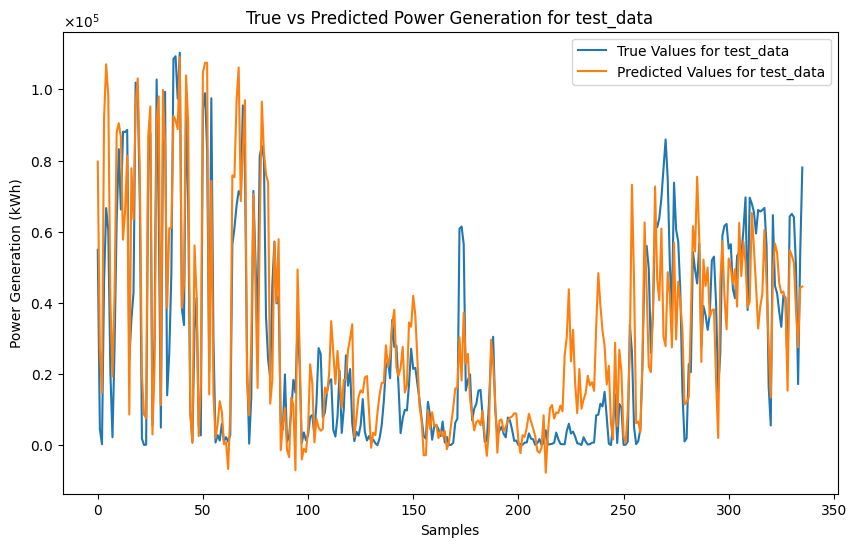

MAE: 11611.602777390253
MSE: 242036786.0590338
RMSE: 15557.53148989369
MAPE: 597.1783058520898


In [ ]:
# 讀取測試數據
test_data = pd.read_csv('活頁簿1.xlsx - 工作表9.csv', encoding='utf-8')
# 1. 前處理 test_data（假設 test_data 已經被讀取）
test_data.replace(['Ｘ', '/', '--'], np.nan, inplace=True)
for column in test_data.columns:
    if column not in ['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']:
        test_data[column] = pd.to_numeric(test_data[column], errors='coerce')
for column in test_data.columns:
    if column not in ['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']:
        monthly_avg = test_data.groupby('Month')[column].transform('mean')
        test_data[column] = test_data[column].fillna(monthly_avg)

# 創建滯後特徵、移動平均特徵和損耗率
# 模擬風機損耗率
initial_decay_rate = 0.1
monthly_increase_factor = 1.2
yearly_increase_factor = 1.5
# (與之前處理 data 相同)
decay_rate_list = []
current_decay_rate = initial_decay_rate
for idx, row in test_data.iterrows():
    if idx > 0:
        if test_data.loc[idx, 'Year'] != test_data.loc[idx - 1, 'Year']:
            current_decay_rate *= yearly_increase_factor
        elif test_data.loc[idx, 'Month'] != test_data.loc[idx - 1, 'Month']:
            current_decay_rate *= monthly_increase_factor
    decay_rate_list.append(current_decay_rate)

test_data['損耗率'] = decay_rate_list

for feature in lag_features:
    for lag in range(10, 12):
        test_data[f'{feature}_lag{lag}'] = test_data[feature].shift(lag)

for feature in lag_features:
    for window in window_sizes:
        test_data[f'{feature}_ma{window}'] = test_data[feature].rolling(window=window).mean()

test_data.dropna(inplace=True)

# 2. 資料標準化
test_data_scaled = scaler.transform(test_data.drop(columns=['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']))

# 將標準化資料轉回 DataFrame
test_data_scaled = pd.DataFrame(test_data_scaled, columns=test_data.columns.drop(['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']))

# 提取目標變量
y_test_data = test_data_scaled['發電量(度)/Power Generation(kWh)']

# 加強特定特徵的權重
test_data_scaled[weighted_features] = test_data_scaled[weighted_features] * 2

# 3. 特徵選擇和擴展
X_test = test_data_scaled[selected_feature_names]
for feature in mandatory_features:
    if feature not in selected_feature_names:
        X_test = np.concatenate([X_test, test_data_scaled[[feature]]], axis=1)

# 4. 擴展以匹配模型輸入形狀
X_test = np.expand_dims(X_test, axis=1)

# 5. 進行預測
y_test_pred_scaled = model.predict(X_test)
y_test_pred_original = y_test_pred_scaled.flatten() * scale_scaler[0] + mean_scaler[0]
y_test_data_original = y_test_data.values * scale_scaler[0] + mean_scaler[0]

# 6. 繪製預測結果
plt.figure(figsize=(10, 6))
plt.plot(y_test_data_original, label='True Values for test_data')
plt.plot(y_test_pred_original, label='Predicted Values for test_data')
plt.title('True vs Predicted Power Generation for test_data')
plt.xlabel('Samples')
plt.ylabel('Power Generation (kWh)')

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

plt.legend()
plt.show()

from sklearn.metrics import mean_absolute_error, mean_squared_error

def mean_absolute_percentage_error(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
# 7. 計算評估指標
mae = mean_absolute_error(y_test_data_original, y_test_pred_original)
mse = mean_squared_error(y_test_data_original, y_test_pred_original)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_data_original, y_test_pred_original)

print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'MAPE: {mape}')



11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


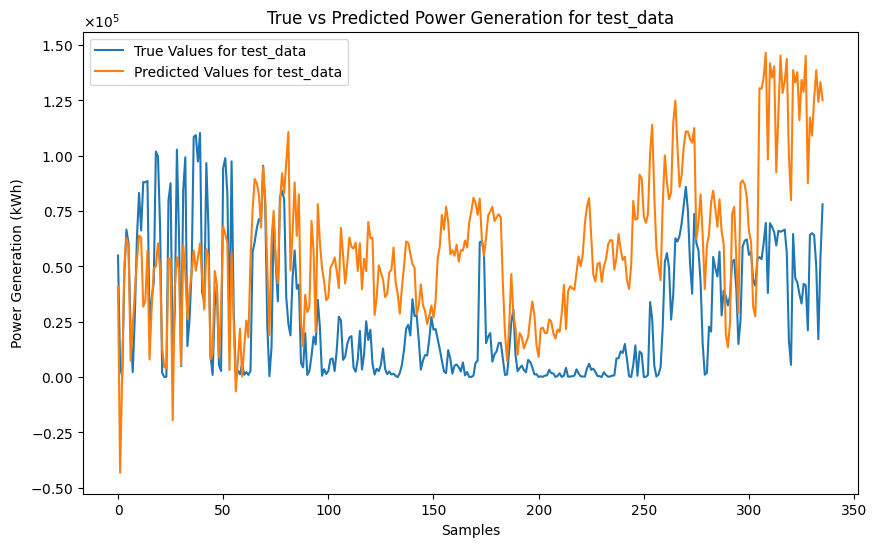

MAE: 37235.50442940848
MSE: 1954497084.8583028
RMSE: 44209.69446691871
MAPE: 3642.7387310467843


In [ ]:
# 讀取測試數據
test_data = pd.read_csv('活頁簿1.xlsx - 工作表9.csv', encoding='utf-8')
# 1. 前處理 test_data（假設 test_data 已經被讀取）
test_data.replace(['Ｘ', '/', '--'], np.nan, inplace=True)
for column in test_data.columns:
    if column not in ['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']:
        test_data[column] = pd.to_numeric(test_data[column], errors='coerce')
for column in test_data.columns:
    if column not in ['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']:
        monthly_avg = test_data.groupby('Month')[column].transform('mean')
        test_data[column] = test_data[column].fillna(monthly_avg)

# 創建滯後特徵、移動平均特徵和損耗率
# 模擬風機損耗率
initial_decay_rate = 0.1
monthly_increase_factor = 1.2
yearly_increase_factor = 1.5
# (與之前處理 data 相同)
decay_rate_list = []
current_decay_rate = initial_decay_rate
for idx, row in test_data.iterrows():
    if idx > 0:
        if test_data.loc[idx, 'Year'] != test_data.loc[idx - 1, 'Year']:
            current_decay_rate *= yearly_increase_factor
        elif test_data.loc[idx, 'Month'] != test_data.loc[idx - 1, 'Month']:
            current_decay_rate *= monthly_increase_factor
    decay_rate_list.append(current_decay_rate)

test_data['損耗率'] = decay_rate_list

for feature in lag_features:
    for lag in range(10, 12):
        test_data[f'{feature}_lag{lag}'] = test_data[feature].shift(lag)

for feature in lag_features:
    for window in window_sizes:
        test_data[f'{feature}_ma{window}'] = test_data[feature].rolling(window=window).mean()

test_data.dropna(inplace=True)

# 2. 資料標準化
test_data_scaled = scaler.transform(test_data.drop(columns=['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']))

# 將標準化資料轉回 DataFrame
test_data_scaled = pd.DataFrame(test_data_scaled, columns=test_data.columns.drop(['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']))

# 提取目標變量
y_test_data = test_data_scaled['發電量(度)/Power Generation(kWh)']

# 加強特定特徵的權重
test_data_scaled[weighted_features] = test_data_scaled[weighted_features] * 2

# 3. 特徵選擇和擴展
X_test = test_data_scaled[selected_feature_names]
for feature in mandatory_features:
    if feature not in selected_feature_names:
        X_test = np.concatenate([X_test, test_data_scaled[[feature]]], axis=1)

# 4. 擴展以匹配模型輸入形狀
X_test = np.expand_dims(X_test, axis=1)

# 5. 進行預測
y_test_pred_scaled = model.predict(X_test)
y_test_pred_original = y_test_pred_scaled.flatten() * scale_scaler[0] + mean_scaler[0]
y_test_data_original = y_test_data.values * scale_scaler[0] + mean_scaler[0]

# 6. 繪製預測結果
plt.figure(figsize=(10, 6))
plt.plot(y_test_data_original, label='True Values for test_data')
plt.plot(y_test_pred_original, label='Predicted Values for test_data')
plt.title('True vs Predicted Power Generation for test_data')
plt.xlabel('Samples')
plt.ylabel('Power Generation (kWh)')

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

plt.legend()
plt.show()

from sklearn.metrics import mean_absolute_error, mean_squared_error

def mean_absolute_percentage_error(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
# 7. 計算評估指標
mae = mean_absolute_error(y_test_data_original, y_test_pred_original)
mse = mean_squared_error(y_test_data_original, y_test_pred_original)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_data_original, y_test_pred_original)

print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'MAPE: {mape}')



12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


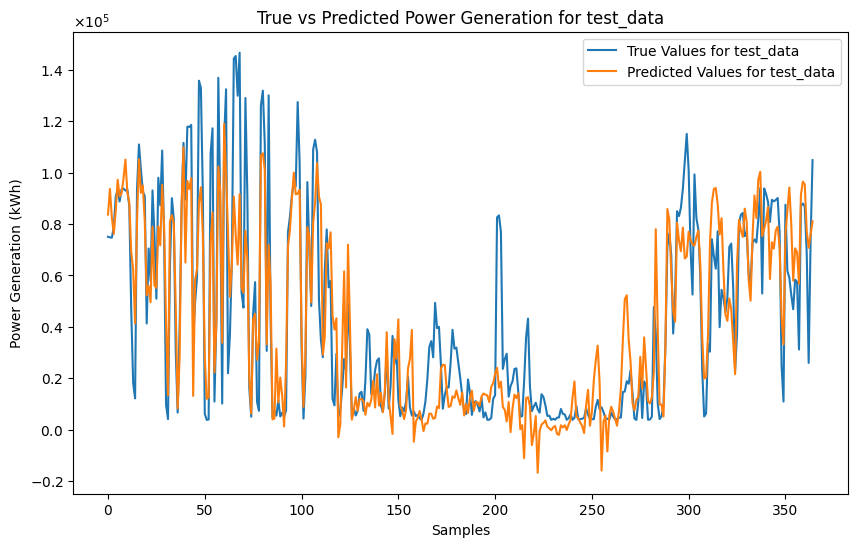

MAE: 13691.371727950907
MSE: 362791964.8036504
RMSE: 19047.098592794926
MAPE: 67.98715847985221


In [ ]:
# 讀取測試數據
test_data = pd.read_csv('活頁簿1.xlsx - 工作表9.csv', encoding='utf-8')
# 1. 前處理 test_data（假設 test_data 已經被讀取）
test_data.replace(['Ｘ', '/', '--'], np.nan, inplace=True)
for column in test_data.columns:
    if column not in ['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']:
        test_data[column] = pd.to_numeric(test_data[column], errors='coerce')
for column in test_data.columns:
    if column not in ['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']:
        monthly_avg = test_data.groupby('Month')[column].transform('mean')
        test_data[column] = test_data[column].fillna(monthly_avg)


# 2. 資料標準化
scaler = StandardScaler()
test_data_scaled = scaler.fit_transform(test_data.drop(columns=['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']))

# 將標準化資料轉回 DataFrame
test_data_scaled = pd.DataFrame(test_data_scaled, columns=test_data.columns.drop(['Year', 'Month', 'day', '能源別/Type of Energy', '發電站名稱/Station Name']))

# 提取目標變量
y_test_data = test_data_scaled['發電量(度)/Power Generation(kWh)']

# 創建特徵矩陣
X_test = test_data_scaled.drop(columns=['發電量(度)/Power Generation(kWh)'])

# 4. 擴展以匹配模型輸入形狀
X_test = np.expand_dims(X_test, axis=1)  # 確保這裡的 shape 是正確的

# 5. 進行預測
y_test_pred_scaled = model.predict(X_test)
y_test_pred_original = y_test_pred_scaled.flatten() * scale_scaler[0] + mean_scaler[0]
y_test_data_original = y_test_data.values * scale_scaler[0] + mean_scaler[0]

# 6. 繪製預測結果
plt.figure(figsize=(10, 6))
plt.plot(y_test_data_original, label='True Values for test_data')
plt.plot(y_test_pred_original, label='Predicted Values for test_data')
plt.title('True vs Predicted Power Generation for test_data')
plt.xlabel('Samples')
plt.ylabel('Power Generation (kWh)')

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

plt.legend()
plt.show()

from sklearn.metrics import mean_absolute_error, mean_squared_error

def mean_absolute_percentage_error(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
# 7. 計算評估指標
mae = mean_absolute_error(y_test_data_original, y_test_pred_original)
mse = mean_squared_error(y_test_data_original, y_test_pred_original)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_data_original, y_test_pred_original)

print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'MAPE: {mape}')



# 白沙鄉用電預測

In [ ]:
import pandas as pd

# 假設有CSV文件包含所有所需數據
data3 = pd.read_excel('/content/avg用電.xlsx', sheet_name='工作表2')

# 查看數據
print(data3.head())


   Year  Month  售電度數(當月)
0  2018      1    801768
1  2018      2   2705604
2  2018      3    812767
3  2018      4   3174930
4  2018      5   1030259


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Streaming output truncated to the last 5000 lines.
Epoch 502/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 0.1673 - mae: 0.1673 - val_loss: 0.3906 - val_mae: 0.3906
Epoch 503/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 0.1610 - mae: 0.1610 - val_loss: 0.3184 - val_mae: 0.3184
Epoch 504/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 0.2119 - mae: 0.2119 - val_loss: 0.2337 - val_mae: 0.2337
Epoch 505/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 0.2775 - mae: 0.2775 - val_loss: 0.1833 - val_mae: 0.1833
Epoch 506/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.1789 - mae: 0.1789 - val_loss: 0.1334 - val_mae: 0.1334
Epoch 507/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 0.1641 - mae: 0.1641 - val_loss: 0.1665 - val_mae: 0.1665
Epoch 508/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 0.1888 - mae: 0.1888 - val_loss: 0.2494 - val_mae: 0.2494
Epoch 509/3000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - loss: 0.1821 - mae: 0.1821 - val_loss: 0.2922 - val_m

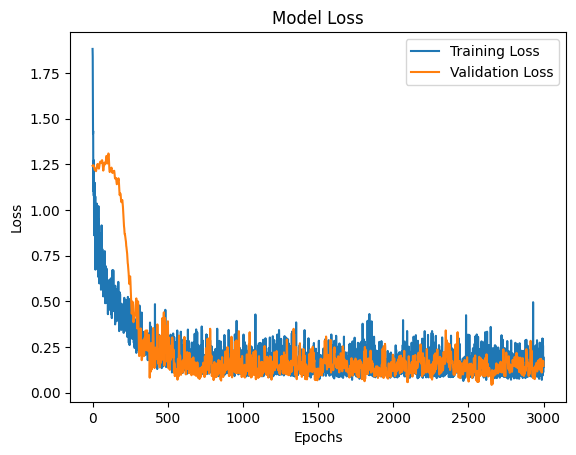

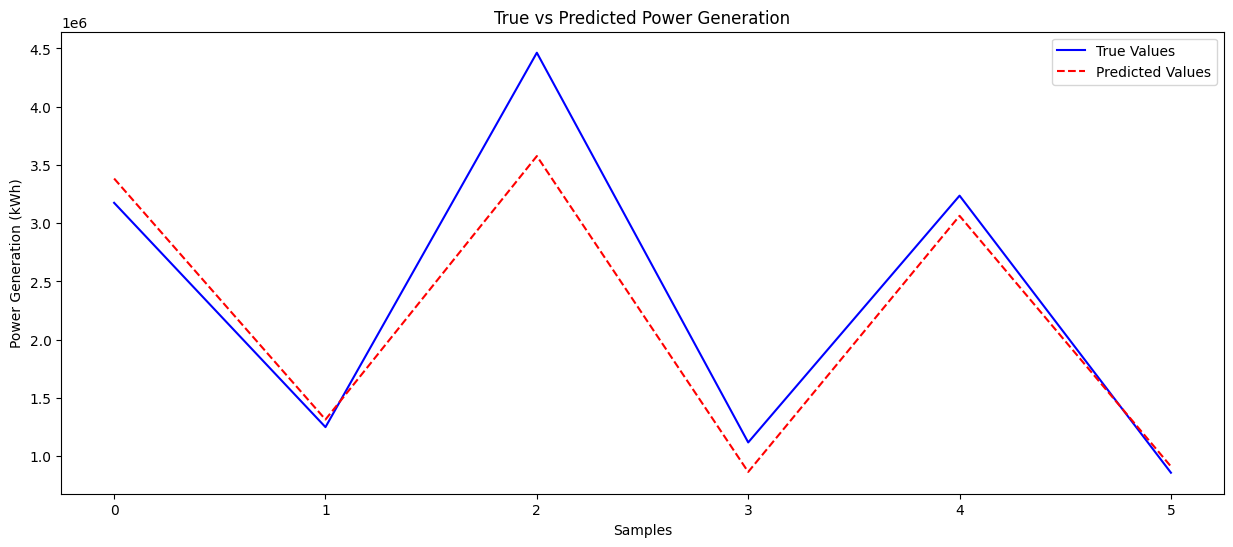

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, BatchNormalization, Dropout
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 提取特徵和目標變量
X = data3[['售電度數(當月)']].values
y = data3[['售電度數(當月)']].shift(-1).fillna(0).values  # 目標變量是下一月的電力需求

# 標準化数据
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.transform(y)

# 準備LSTM模型的數據
def create_sequences(data, time_step):
    X_seq, y_seq = [], []
    for i in range(len(data) - time_step):
        X_seq.append(data[i:i + time_step])
        y_seq.append(data[i + time_step])
    return np.array(X_seq), np.array(y_seq)

time_step = 3
X_seq, y_seq = create_sequences(X_scaled, time_step)

# 拆分資料集
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.1, random_state=42)

# 構建LSTM模型
model = Sequential()
model.add(LSTM(256, activation='relu', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(LSTM(256, activation='relu', return_sequences=True))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(LSTM(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mae', metrics=['mae'])

# 訓練模型
history = model.fit(X_train, y_train, epochs=3000, batch_size=32, validation_split=0.1, verbose=1)

# 預測數據
y_pred_scaled = model.predict(X_test)

# 反標準化
X_test_unscaled = scaler.inverse_transform(X_test[:, -1, :])  # 獲取預測用的最後一步數據
y_test_unscaled = scaler.inverse_transform(y_test)
y_pred_unscaled = scaler.inverse_transform(y_pred_scaled)
# 評估模型
mae = model.evaluate(X_test, y_test_unscaled, verbose=0)[1]
print(f'Mean Absolute Error: {mae}')

# 繪製訓練過程中的損失圖
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 繪製結果
plt.figure(figsize=(15, 6))
plt.plot(range(len(y_test_unscaled)), y_test_unscaled, color='blue', label='True Values')
plt.plot(range(len(y_pred_unscaled)), y_pred_unscaled, color='red', linestyle='--', label='Predicted Values')
plt.title('True vs Predicted Power Generation')
plt.xlabel('Samples')
plt.ylabel('Power Generation (kWh)')
plt.legend()
plt.show()


# 白沙2023實際用電

   Year  Month  售電度數(度)
0  2023      1   879472
1  2023      2  3201676
2  2023      3   800260
3  2023      4  3047844
4  2023      5   939638
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step


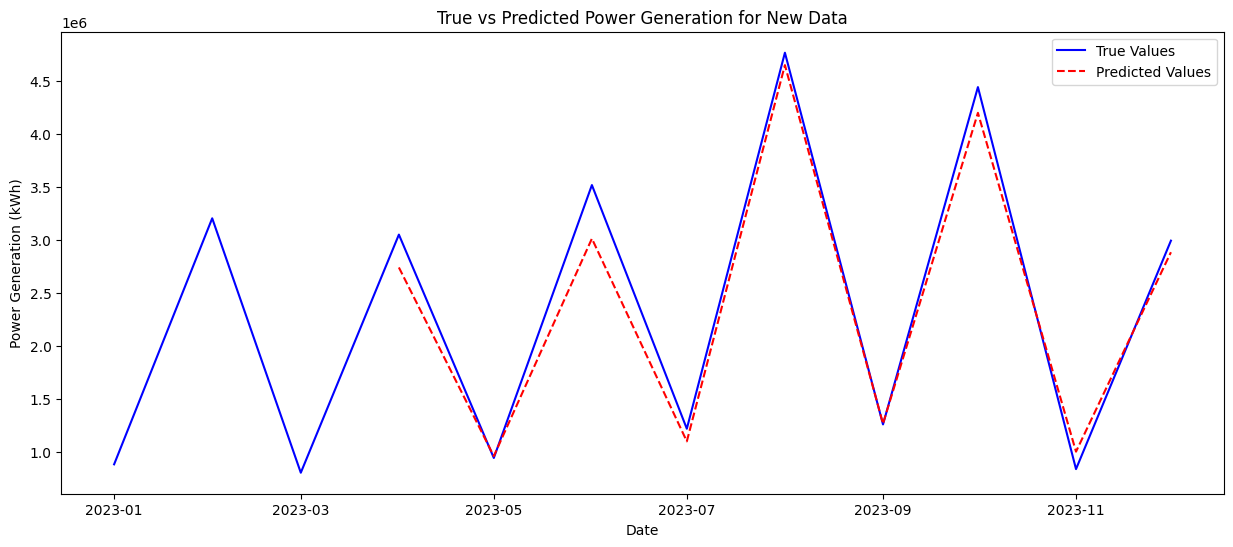

ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 6
'y' sizes: 9


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# 加載數據
data6 = pd.read_excel('/content/2023白沙實際用電.xlsx')

print(data6.head())

# 确保數據中有Year, Month和售電度数列
data6['Date'] = pd.to_datetime(data6[['Year', 'Month']].assign(day=1))
data6.set_index('Date', inplace=True)

# 提取特徵
X_new = data6[['售電度數(度)']].values

# 標準化新數據
scaler = StandardScaler()
X_new_scaled = scaler.fit_transform(X_new)

# 準備LSTM模型的數據
def create_sequences(data, time_step):
    X_seq = []
    for i in range(len(data) - time_step):
        X_seq.append(data[i:i + time_step])
    return np.array(X_seq)

time_step = 3
X_new_seq = create_sequences(X_new_scaled, time_step)

if len(X_new_seq) == 0:
    raise ValueError(f"Input data length ({len(X_new_scaled)}) is less than time_step ({time_step}).")


# 預測新的數據
y_new_pred_scaled = model.predict(X_new_seq)

# 反標準化預測结果
y_new_pred_unscaled = y_new_pred_scaled * scaler.scale_[-1] + scaler.mean_[-1]

#獲得時間索引
time_index = data6.index[time_step:]

# 繪製结果
plt.figure(figsize=(15, 6))
plt.plot(data6.index, data6['售電度數(度)'], color='blue', label='True Values')  # 真實值
plt.plot(time_index, y_new_pred_unscaled.flatten(), color='red', linestyle='--', label='Predicted Values')  # 预測值
plt.title('True vs Predicted Power Generation for New Data')
plt.xlabel('Date')
plt.ylabel('Power Generation (kWh)')
plt.legend()
plt.show()

# 評估模型
mse = model.evaluate(X_test, y_new_pred_unscaled)
print(f'Mean Squared Error: {mse}')


# 電池儲能系統
中屯風電廠與白沙鄉電力需求

<ipython-input-179-80367bdcd0cb>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_wind_power['date'] = pd.to_datetime(daily_wind_power[['Year', 'Month', 'day']])
<ipython-input-179-80367bdcd0cb>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_wind_power['month'] = daily_wind_power['date'].dt.to_period('M')
<ipython-input-179-80367bdcd0cb>:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '1534611.6' has dtype incompatible wi

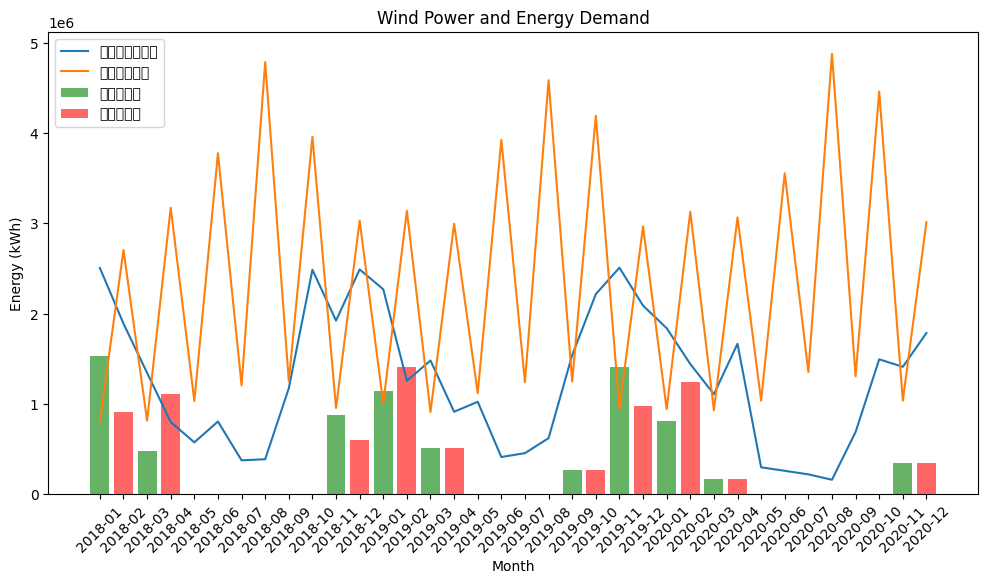

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

# 提取每日風電發電量數據
daily_wind_power = data[['Year', 'Month', 'day', '發電量(度)/Power Generation(kWh)']]

# 將年、月、日合併到一個日期列中
daily_wind_power['date'] = pd.to_datetime(daily_wind_power[['Year', 'Month', 'day']])
daily_wind_power['month'] = daily_wind_power['date'].dt.to_period('M')

# 將每日發電量匯總至每月
monthly_wind_power = daily_wind_power.groupby('month')['發電量(度)/Power Generation(kWh)'].sum().reset_index()
monthly_wind_power.rename(columns={'發電量(度)/Power Generation(kWh)': 'monthly_wind_power'}, inplace=True)

# 確保 data4 中的年份和月份正確組合成日期時間
data3['month'] = pd.to_datetime(data3[['Year', 'Month']].assign(day=1))

# 複製 data4 進行處理
monthly_energy_demand = data3.copy()
monthly_energy_demand['month'] = monthly_energy_demand['month'].dt.to_period('M')

# 合併每月風電和能源需求數據
energy_data = pd.merge(monthly_wind_power, monthly_energy_demand, on='month')
energy_data.rename(columns={'售電度數(當月)': 'monthly_energy_demand'}, inplace=True)

# 電池儲存參數
battery_capacity = 5000000  # 電池容量（kWh）
battery_charge = 0          # 初始電池電量
charge_efficiency = 0.9     # 充電效率
discharge_efficiency = 0.9  # 放電效率

# 模擬電池充放電
energy_data['battery_charge'] = 0
energy_data['battery_discharge'] = 0

for i in range(len(energy_data)):
    surplus_energy = energy_data.loc[i, 'monthly_wind_power'] - energy_data.loc[i, 'monthly_energy_demand']
    if surplus_energy > 0:
        # 充電
        energy_data.loc[i, 'battery_charge'] = min(surplus_energy * charge_efficiency, battery_capacity - battery_charge)
        battery_charge += energy_data.loc[i, 'battery_charge']
    else:
        # 放電
        needed_energy = abs(surplus_energy) / discharge_efficiency
        energy_data.loc[i, 'battery_discharge'] = min(needed_energy, battery_charge)
        battery_charge -= energy_data.loc[i, 'battery_discharge']

# 繪製結果
plt.figure(figsize=(12, 6))
plt.plot(energy_data['month'].astype(str), energy_data['monthly_wind_power'], label='每月風電發電量')
plt.plot(energy_data['month'].astype(str), energy_data['monthly_energy_demand'], label='每月能源需求')
plt.bar(energy_data['month'].astype(str), energy_data['battery_charge'], label='電池充電量', alpha=0.6,  color='green')
plt.bar(energy_data['month'].astype(str), energy_data['battery_discharge'], label='電池放電量', alpha=0.6,  color='red')
plt.xlabel('Month')
plt.ylabel('Energy (kWh)')
plt.title('Wind Power and Energy Demand')
plt.legend()
plt.xticks(rotation=45)
plt.show()